# Assignment 1, Task B: Regression using tree methods.

## The data:
In this QSAR exercise, water solubility of various molecules is to be investigated. The dataset in use is the ESOL Dataset assembled by John Delaney, as provided here: https://huggingface.co/datasets/scikit-fingerprints/MoleculeNet_ESOL/tree/main.


## The tasks:
1) Inspect the data and clean if needed. Adhere to good practices!
2) Calculate some molecular descriptors via the smiles strings using rdkit (partial snippet provided)
3) Create a feature matrix X and a target vector y
4) Three different models should be trained on the molecular descriptors and evaluated according to RMSE and their R2 score to compare their performance. For each model, additionally, the overfitting needs to be addressed.

These three models have to be compared:
- `DecisionTreeRegressor`
- `RandomForestRegressor`
- `GradientBoostingRegressor`

For a first baseline performance, the models can be used as provided by `scikit`, but should include a random seed. 

5) Based on the model performance, take the best performing algorithm and optimise its hyperparameters using `GridSearchCV`

6) Assess the feature importance

7) Conclusion and discussion: Provide answers to the questions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("esol.csv")
df.head()

,SMILES,label
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


## 1. Inspect and clean the data
Gain some overview of the data and assess NaNs and duplicates and clean if needed.

In [3]:
# Genral information on the data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMILES  1128 non-null   object 
 1   label   1128 non-null   float64
dtypes: float64(1), object(1)
memory usage: 17.8+ KB


,label
count,1128.000000
mean,-3.050102
std,2.096441
min,-11.600000
25%,-4.317500
50%,-2.860000
75%,-1.600000
max,1.580000


In [4]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
# Checking for NaNs
df.isna().sum()

SMILES    0
label     0
dtype: int64

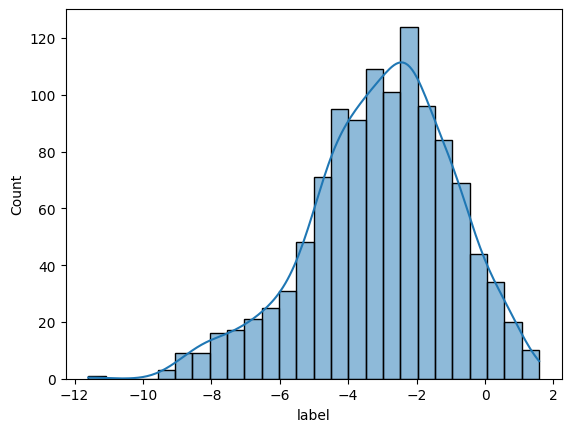

In [9]:
# Visualizing the distribution of the target variable (solubility)
sns.histplot(df["label"], kde=True)
plt.show()

## 2. Create molecular descriptors from the Smiles
Use the snippet below to calculate descriptors from the SMILES strings. Make sure to include the molecular weight, the logP and choose three more which you believe to impact the solubility, e.g. https://greglandrum.github.io/rdkit-blog/posts/2022-12-23-descriptor-tutorial.html or here: https://deepwiki.com/rdkit/rdkit/6.1-molecular-descriptors-and-properties 

In [10]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "NumHeteroatoms": Descriptors.NumHeteroatoms(mol),
        "NumAromaticRings": Descriptors.NumAromaticRings(mol),
        "TPSA": Descriptors.TPSA(mol)
    })

# Apply to dataframe
descriptor_df = df["SMILES"].apply(compute_descriptors)

# Combine descriptors with original data
df_full = pd.concat([df, descriptor_df], axis=1)

# Remove rows where descriptor calculation failed
df_full = df_full.dropna()
df_full.head()

,SMILES,label,MolWt,LogP,NumHeteroatoms,NumAromaticRings,TPSA
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,12.0,1.0,202.32
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,3.0,2.0,42.24
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,1.0,0.0,17.07
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,0.0,5.0,0.00
4,c1ccsc1,-1.33,84.143,1.74810,1.0,1.0,0.00


In [14]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SMILES            1128 non-null   object 
 1   label             1128 non-null   float64
 2   MolWt             1128 non-null   float64
 3   LogP              1128 non-null   float64
 4   NumHeteroatoms    1128 non-null   float64
 5   NumAromaticRings  1128 non-null   float64
 6   TPSA              1128 non-null   float64
dtypes: float64(6), object(1)
memory usage: 61.8+ KB


## 3. Create the feature matrix and target vector

In [19]:
# Features (X) and target (y)
X = df_full[[
    "MolWt",
    "LogP",
    "NumHeteroatoms",
    "NumAromaticRings",
    "TPSA"
]]

y = df_full["label"]

## 4. Train the models
Use a classic train-test split of 0.2 including a random seed. For training and predicting labels, take note of the time the process takes for each model (does not necessarily have to be coded, can also be estimated). Make sure to predict labels for both training and test splits in order to identify overfitting. Use the RMSE and R2 as metrics for evaluation of the baseline performance of the models. Make sure to consider overfitting.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
)

In [22]:
# Decision Tree Regressor

dt_default = DecisionTreeRegressor(random_state=42)

dt_default.fit(X_train, y_train)

y_pred_train_DT = dt_default.predict(X_train)

y_pred_test_DT = dt_default.predict(X_test)

In [23]:
# Random Forest Regressor

rf_default = RandomForestRegressor(random_state=42)

rf_default.fit(X_train, y_train)

y_pred_test_RF = rf_default.predict(X_test) 

y_pred_train_RF = rf_default.predict(X_train) 

In [25]:
# Gradient Boosting Regressor

gb_default = GradientBoostingRegressor(random_state=42)

gb_default.fit(X_train, y_train)

y_pred_test_GB = gb_default.predict(X_test)

y_pred_train_GB = gb_default.predict(X_train)

In [49]:
print("Decision Tree:")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_DT)))
print("Train R2:", r2_score(y_train, y_pred_train_DT))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_DT)))
print("Test R2:", r2_score(y_test, y_pred_test_DT))
print("------------------------------------------------")
print("Random Forest:")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_RF)))
print("Train R2:", r2_score(y_train, y_pred_train_RF))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_RF)))
print("Test R2:", r2_score(y_test, y_pred_test_RF))
print("------------------------------------------------")
print("Gradient Boosting:")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_GB)))
print("Train R2:", r2_score(y_train, y_pred_train_GB))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_GB)))
print("Test R2:", r2_score(y_test, y_pred_test_GB))

Decision Tree:
Train RMSE: 0.12142489737867623
Train R2: 0.9965765027162931
Test RMSE: 0.975874287309215
Test R2: 0.7912018818715112
------------------------------------------------
Random Forest:
Train RMSE: 0.28450170721298057
Train R2: 0.9812057823904116
Test RMSE: 0.7396526701043453
Test R2: 0.8800515919415209
------------------------------------------------
Gradient Boosting:
Train RMSE: 0.5078572624499958
Train R2: 0.9401122727206078
Test RMSE: 0.7300772985173039
Test R2: 0.8831371378743942


Use the best model and plot the predictions over the true values (y_test vs. y_pred) in a scatterplot.

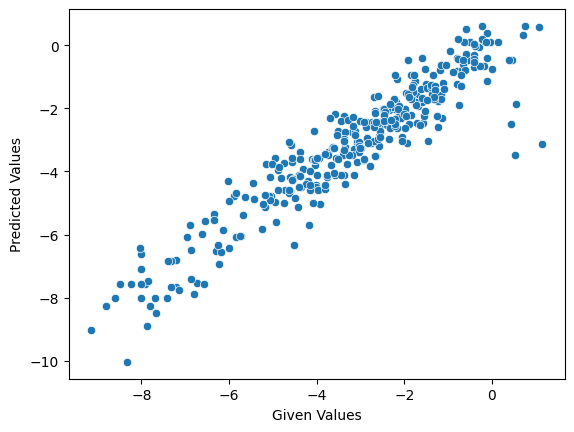

In [28]:
# Gradient Boosting performed the best as it has the best test scores and also overfits less than the other two models

sns.scatterplot(x=y_test, y=y_pred_test_GB)
plt.xlabel("Given Values")
plt.ylabel("Predicted Values")
plt.show()


## 5. Hyperparameter tuning of the best model
Use GridSearchCV to optimise the hyperparameters for the best model. Use a reasonable parameter grid (2-3 different values max. for each parameter you want to optimise).

In [33]:
param_grid = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,3]
}

In [34]:
grid = GridSearchCV(
    gb_default,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 3], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time f

Extract the best model

In [35]:
best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


Useful tool: Export (and reimport) your best model:

In [36]:
import joblib
# export the best model:
joblib.dump(best_model, "best_model.joblib")
# reload the best model:
loaded_model = joblib.load("best_model.joblib")

Evaluate the best model on the test set.

In [48]:
y_pred_test_tuned = loaded_model.predict(X_test)
y_pred_train_tuned = loaded_model.predict(X_train)

print("Tuned parameters:", grid.best_params_)
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_tuned)))
print("Train R2:", r2_score(y_train, y_pred_train_tuned))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_tuned)))
print("Test R2:", r2_score(y_test, y_pred_test_tuned))

Tuned parameters: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Train RMSE: 0.5763607303646638
Train R2: 0.9228664600096763
Test RMSE: 0.7345850691412386
Test R2: 0.8816895725813272


Plot the predicted vs. the true solubility again!

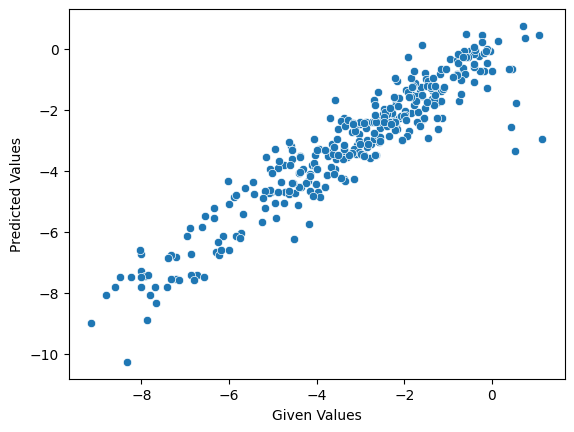

In [39]:
sns.scatterplot(x=y_test, y=y_pred_test_tuned)
plt.xlabel("Given Values")
plt.ylabel("Predicted Values")
plt.show()

## 6. Feature importance
Investigate the feature importance for your best model using the snippet below (but with your descriptors).

In [42]:
feature_names = [
    "MolWt", "LogP", "NumHeteroatoms", "NumAromaticRings", "TPSA"
]

importances = best_model.feature_importances_

for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"{name}: {imp:.3f}")

LogP: 0.823
MolWt: 0.103
NumHeteroatoms: 0.039
TPSA: 0.031
NumAromaticRings: 0.004


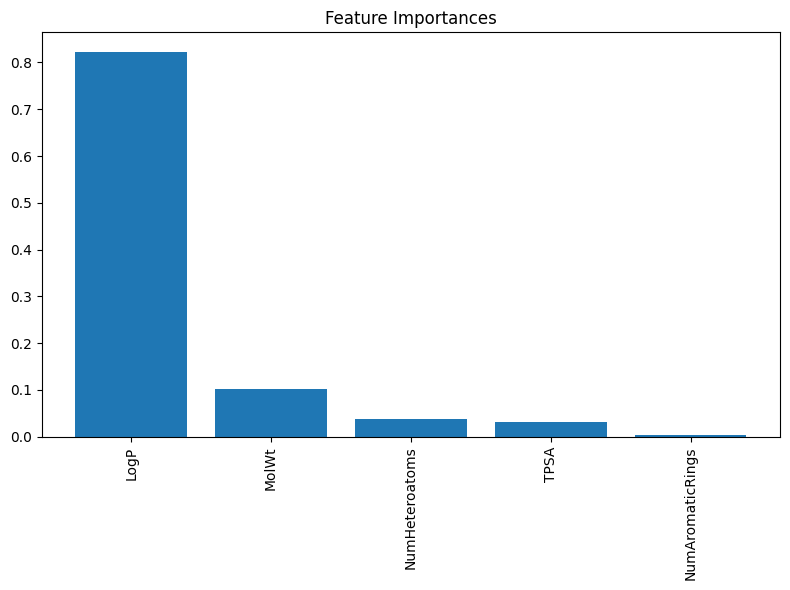

In [46]:
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.bar(range(5), importances[indices])
plt.xticks(range(5), X.columns[indices], rotation=90)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

## 7. Conclusion and discussion
- Which model performed the best?

Gradient Boosting performed the best.
- Which model showed the worst overfitting?

Decision Tree showed the most overfitting.
- Did the GridSearchCV improve the model? Is the difference to be considered significant?

Tuned model did not improve performance of test significantly, it was even slightly worse than the non tuned version.
- Which descriptors (besides the logP) had the most influence on the solubility?

LogP had by far the most influence on solubility. Number of aromatic rings nearly had no influence on the solubility.
